In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
train_path = r"D:\potato leaf disease detection\dataset\Train"
valid_path = r"D:\potato leaf disease detection\dataset\Valid"
test_path = r"D:\potato leaf disease detection\dataset\Test"

print("Train Path:", train_path)
print("Valid Path:", valid_path)
print("Test Path:", test_path)

Train Path: D:\potato leaf disease detection\dataset\Train
Valid Path: D:\potato leaf disease detection\dataset\Valid
Test Path: D:\potato leaf disease detection\dataset\Test


In [3]:
# function is used to create an image dataset from a directory structure where images are organized into subdirectories representing class labels
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    # batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    # seed=None,
    # validation_split=None,
    # subset=None,
    interpolation="bilinear",
    # follow_links=False,
    # crop_to_aspect_ratio=False
)

Found 900 files belonging to 3 classes.


In [4]:
# Get the class labels
labels = training_set.class_names
print(labels)


['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [5]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    # batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    # seed=None,
    # validation_split=None,
    # subset=None,
    interpolation="bilinear",
    # follow_links=False,
    # crop_to_aspect_ratio=False
)

Found 300 files belonging to 3 classes.


In [6]:
cnn = tf.keras.models.Sequential()

cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Dropout(0.25))

cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))
cnn.add(tf.keras.layers.Dropout(0.4))

cnn.add(tf.keras.layers.Dense(units=3,activation='softmax'))

In [7]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [8]:
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

In [9]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
29/29 [==============================] - 17s 212ms/step - loss: 1.1175 - accuracy: 0.4767 - val_loss: 0.7461 - val_accuracy: 0.6167
Epoch 2/10
29/29 [==============================] - 4s 129ms/step - loss: 0.6130 - accuracy: 0.7189 - val_loss: 0.6098 - val_accuracy: 0.6900
Epoch 3/10
29/29 [==============================] - 4s 138ms/step - loss: 0.5233 - accuracy: 0.7622 - val_loss: 0.6343 - val_accuracy: 0.7200
Epoch 4/10
29/29 [==============================] - 4s 148ms/step - loss: 0.4104 - accuracy: 0.8289 - val_loss: 0.3999 - val_accuracy: 0.8267
Epoch 5/10
29/29 [==============================] - 5s 161ms/step - loss: 0.2813 - accuracy: 0.8900 - val_loss: 0.2432 - val_accuracy: 0.9267
Epoch 6/10
29/29 [==============================] - 5s 160ms/step - loss: 0.1921 - accuracy: 0.9322 - val_loss: 0.1642 - val_accuracy: 0.9400
Epoch 7/10
29/29 [==============================] - 4s 138ms/step - loss: 0.1732 - accuracy: 0.9289 - val_loss: 0.2882 - val_accuracy: 0.8933
Epoch

In [10]:
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

29/29 [==============================] - 1s 32ms/step - loss: 0.0754 - accuracy: 0.9700
Training accuracy: 0.9700000286102295


In [11]:
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

10/10 [==============================] - 1s 51ms/step - loss: 0.1560 - accuracy: 0.9300
Validation accuracy: 0.9300000071525574


In [20]:
cnn.save('trained_plant_disease_model.h5')

In [21]:
training_history.history

{'loss': [1.1174633502960205,
  0.6129955649375916,
  0.5232967734336853,
  0.4103872776031494,
  0.28125977516174316,
  0.1920640617609024,
  0.17324090003967285,
  0.17267145216464996,
  0.06567786633968353,
  0.12514473497867584],
 'accuracy': [0.476666659116745,
  0.7188888788223267,
  0.7622222304344177,
  0.8288888931274414,
  0.8899999856948853,
  0.9322222471237183,
  0.9288889169692993,
  0.9322222471237183,
  0.9833333492279053,
  0.9588888883590698],
 'val_loss': [0.7461109757423401,
  0.6098175048828125,
  0.6343459486961365,
  0.39993536472320557,
  0.24318842589855194,
  0.16418582201004028,
  0.28818947076797485,
  0.16893000900745392,
  0.294787734746933,
  0.1560080647468567],
 'val_accuracy': [0.6166666746139526,
  0.6899999976158142,
  0.7200000286102295,
  0.8266666531562805,
  0.9266666769981384,
  0.9399999976158142,
  0.8933333158493042,
  0.9433333277702332,
  0.8933333158493042,
  0.9300000071525574]}

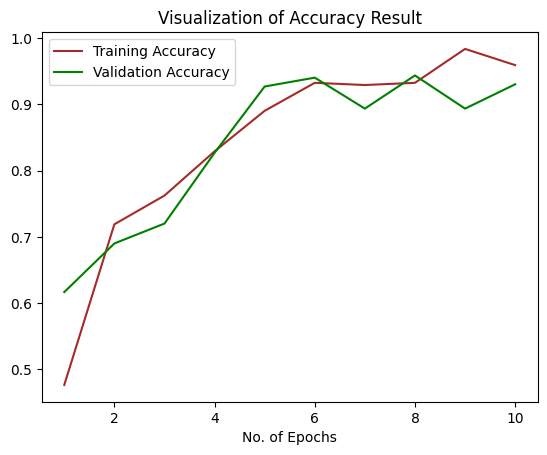

In [22]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='brown',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='green',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()